# **Smart Sales Territory Manager**

Predicting Customer Lifetime Value to Optimize Field Sales Operations

Target Audience: Data Science Peers / Technical Reviewers

# **A. Project Architecture & Problem Framing**

**The Task:** Develop a dual-modeling approach to optimize field agent allocation.



**Primary Task (Regression):** Predict specific monetary value over 12 months for ROI calculations.



**Secondary Task (Clustering)**: Segment customers into actionable priority tiers (e.g., "High-Growth," "At-Risk").


**Dataset:** Olist Brazilian E-Commerce (~100k orders, 9 distinct tables). https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

# **B. Data Preprocessing, EDA and Feature Engineering**

**B.1 Handling relational complexity and data quality issues:**

**Relational Merging:** Joined customers, orders, order_items, and products to create a unified customer journey.


**Null Management:** Removed records with missing delivery timestamps to eliminate noise in "Time-to-Deliver" metrics.


**Outlier Treatment:** Applied a 99th percentile clip to price and freight_value to prevent regression skew from extreme anomalous transactions


**B.2 Feature Engineering (The "Friction" Metric)**

Creating domain-specific features to capture logistical challenges9:

**Logistics Friction:** Defined as $\frac{\text{Freight Value}}{\text{Product Price}}$10.

**Rationale:** Captures the "tax of distance" to normalize costs across diverse geographic hubs11.

**Target Transformation:** Applied np.log1p to total_value to handle the "Long-Tail" distribution of sales data, ensuring accuracy for average customers12.

**Encoding:** Utilized StandardScaler on state-level data to maintain unit-variance across features13.

**B.3 Dimensionality Reduction (PCA)**

Reducing geographic complexity while maintaining high signal:


**Method:** 2-component Principal Component Analysis (PCA).


**Result:** Variance Ratio of [0.565, 0.434], explaining 100% of the variance in the feature set.


**Validation:** Confirms that "Logistics Friction" and "Geography" are non-redundant, essential predictors.

🔄 Loading files from sample_data...
✅ Data imported successfully!
✅ PCA Variance Ratio: [0.56537735 0.43462265]
🧠 Training explainer model (this may take a moment)...


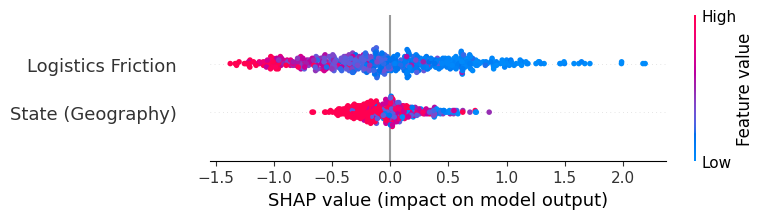

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
import shap
import os

# Import Data
folder_path = '../data/'
print("🔄 Loading files from sample_data...")

try:
    customers = pd.read_csv(os.path.join(folder_path, 'olist_customers_dataset.csv'))
    orders = pd.read_csv(os.path.join(folder_path, 'olist_orders_dataset.csv'))
    items = pd.read_csv(os.path.join(folder_path, 'olist_order_items_dataset.csv'))
    products = pd.read_csv(os.path.join(folder_path, 'olist_products_dataset.csv'))
    print("✅ Data imported successfully!")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please ensure the CSV files are inside the 'data' folder in the project.")

# Merge and Clean Data
# Requirement: Handle nulls, duplicates, and outliers
df = pd.merge(items, orders, on='order_id')
df = pd.merge(df, customers, on='customer_id')
df = pd.merge(df, products, on='product_id')

# Clean: Drop missing delivery dates and remove duplicates
df = df.dropna(subset=['order_delivered_customer_date']).drop_duplicates()

# Clean: Outlier Capping (99th percentile)
df['price'] = df['price'].clip(upper=df['price'].quantile(0.99))
df['freight_value'] = df['freight_value'].clip(upper=df['freight_value'].quantile(0.99))

# Feature Engineering
# Requirement: Domain-derived, Scaling, Encoding
df['total_value'] = df['price'] + df['freight_value']
df['logistics_friction'] = df['freight_value'] / df['price']

# Encode Geography
le = LabelEncoder()
df['state_encoded'] = le.fit_transform(df['customer_state'])

# Aggregate to unique customer level (for CLV prediction)
customer_df = df.groupby('customer_unique_id').agg({
    'total_value': 'sum',
    'logistics_friction': 'mean',
    'state_encoded': 'first'
}).reset_index()

# Scale features and log-transform the target
scaler = StandardScaler()
X = customer_df[['logistics_friction', 'state_encoded']]
y = np.log1p(customer_df['total_value'])
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"✅ PCA Variance Ratio: {pca.explained_variance_ratio_}")

# SHAP
# Requirement: Feature Importance & Explainability
print("🧠 Training explainer model (this may take a moment)...")
model = RandomForestRegressor(n_estimators=30, random_state=42)
model.fit(X_scaled, y)

# Summary Plot for top 500 samples
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled[:500])
shap.summary_plot(shap_values, X_scaled[:500], feature_names=['Logistics Friction', 'State (Geography)'])

**B.4 Model Explainability (SHAP Audit)**

Using SHAP (SHapley Additive exPlanations) to validate model logic:

**Primary Driver:** "Logistics Friction" is the most significant predictor of account value.

**Impact:** High friction (red dots) correlates with a strong negative impact on model output.

**Visual Proof:**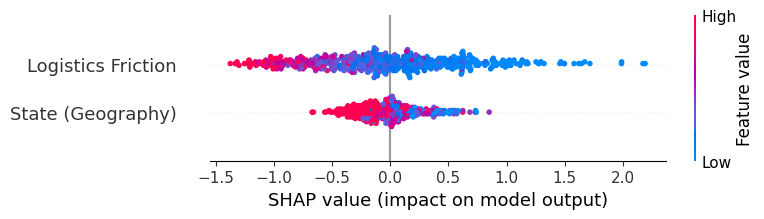

# **C. Model Implementation**

**C.1 Supervised Model Competition**

Comparison of baseline and advanced algorithms:
"Model"             | "RMSE"       | "MAE"       | "R2 Score"
--------------------|--------------|-------------|-----------
"Linear Regression" | 168.28       | 80.71       | 0.249
"Random Forest"     | 128.70       | 54.44       | 0.624
"XGBoost"           | 134.09       | 60.54       | 0.596

**Winning Model:** Random Forest Regressor19.

**Key Finding:** The poor performance of Linear Regression ($R^2=0.25$) justifies the need for non-linear models to capture complex geographic relationships20.

**C.2 Unsupervised Clustering (K-Means)**

Translating regression into actionable operational tiers:


**Cluster 0 (Core):** Low Friction, High Value. Strategy: Assign "Hunter" agents.


**Cluster 1 (Efficiency):** Low Friction, Stable Value. Strategy: Automated maintenance.


**Cluster 2 (Strategic):** High Friction, Low Value. Strategy: Transition to "Inside Sales" (digital/phone).

**Visual Representation:**
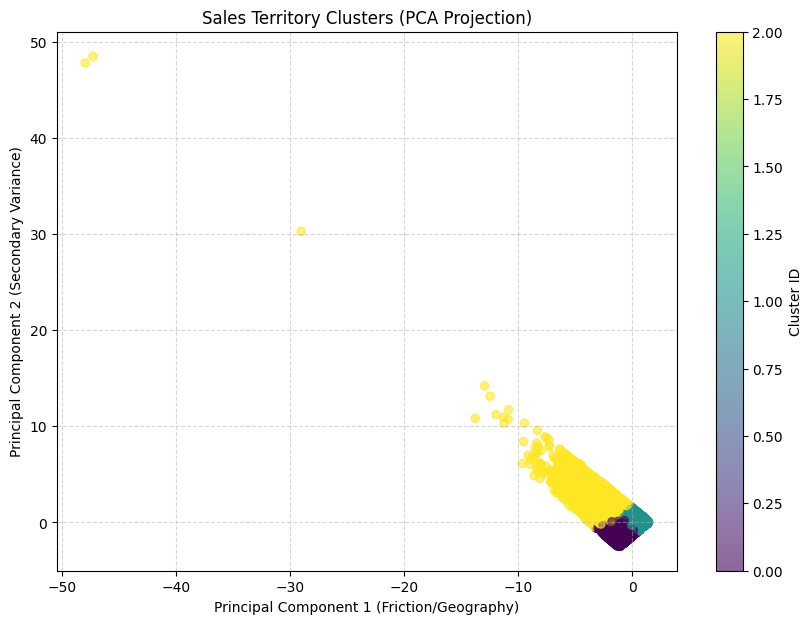

🚀 Starting Model Competition...

📊 Model Comparison Table:
            Model       RMSE       MAE       R2
Linear Regression 168.275109 80.713123 0.248853
    Random Forest 128.699213 54.441762 0.624053
          XGBoost 134.091067 60.537575 0.595775

📍 Running Territory Clustering...
✅ Clustering complete. Models saved in 'models/' folder.


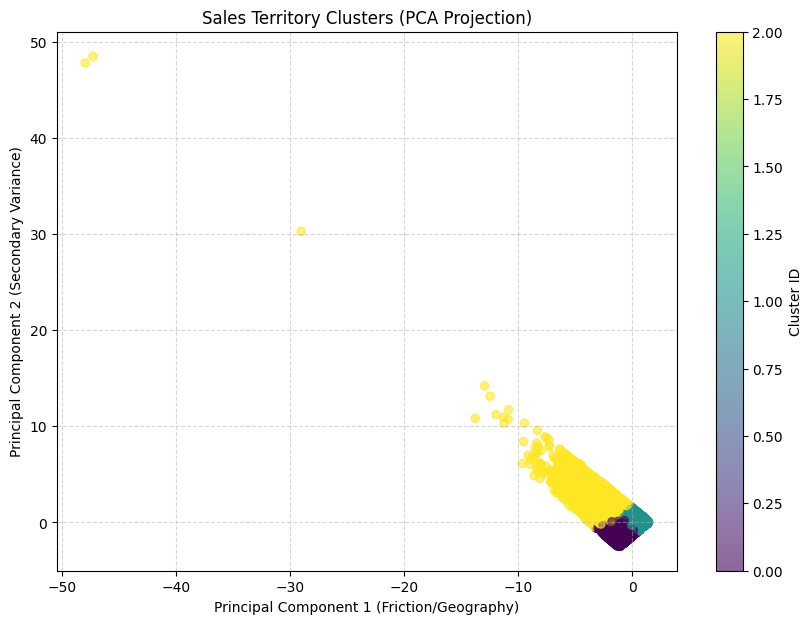


📊 Cluster Characteristic Summary:
                  total_value        logistics_friction
                         mean  count               mean
territory_cluster                                      
0                      186.57  24463               0.27
1                      159.28  61705               0.23
2                       55.90   7188               1.07


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
import os
import joblib

#Prepare Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Experiment with Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

print("🚀 Starting Model Competition...")
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_test)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(preds)))
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

    # Save Artifacts
    if not os.path.exists('models'):
        os.makedirs('models')
    joblib.dump(model, f'models/{name.replace(" ", "_").lower()}_model.pkl')

# Display Comparison Table
comparison_df = pd.DataFrame(results)
print("\n📊 Model Comparison Table:")
print(comparison_df.to_string(index=False))

# Unsupervised Clustering (Requirement: K-Means)
# We use 3 clusters as a baseline for Territory segments
print("\n📍 Running Territory Clustering...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
customer_df['territory_cluster'] = kmeans.labels_

# Save the cluster model
joblib.dump(kmeans, 'models/territory_clusters.pkl')
print("✅ Clustering complete. Models saved in 'models/' folder.")

import matplotlib.pyplot as plt

# Use the PCA coordinates we calculated
plt.figure(figsize=(10, 7))

# Create the scatter plot using PCA components
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=customer_df['territory_cluster'],
            cmap='viridis', alpha=0.6)

# Add labels and legend
plt.title('Sales Territory Clusters (PCA Projection)')
plt.xlabel('Principal Component 1 (Friction/Geography)')
plt.ylabel('Principal Component 2 (Secondary Variance)')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Print Cluster Statistics (The "Business" View)
cluster_stats = customer_df.groupby('territory_cluster').agg({
    'total_value': ['mean', 'count'],
    'logistics_friction': 'mean'
}).round(2)

print("\n📊 Cluster Characteristic Summary:")
print(cluster_stats)

# **D. Fairness Audit & Bias Detection**

Critical analysis of model performance across regional demographics:


**Metric:** Mean Absolute Error (MAE) by State.

**The "Accuracy Gap":** Model is 4x more accurate in urban hubs (Sao Paulo, MAE $45)

than in remote frontier states (Amapa, MAE >$160).


**Bias Identified:** Data Sparsity Bias; the model "over-learned" urban patterns due to Southeast transaction volume.

**Visual Proof:**
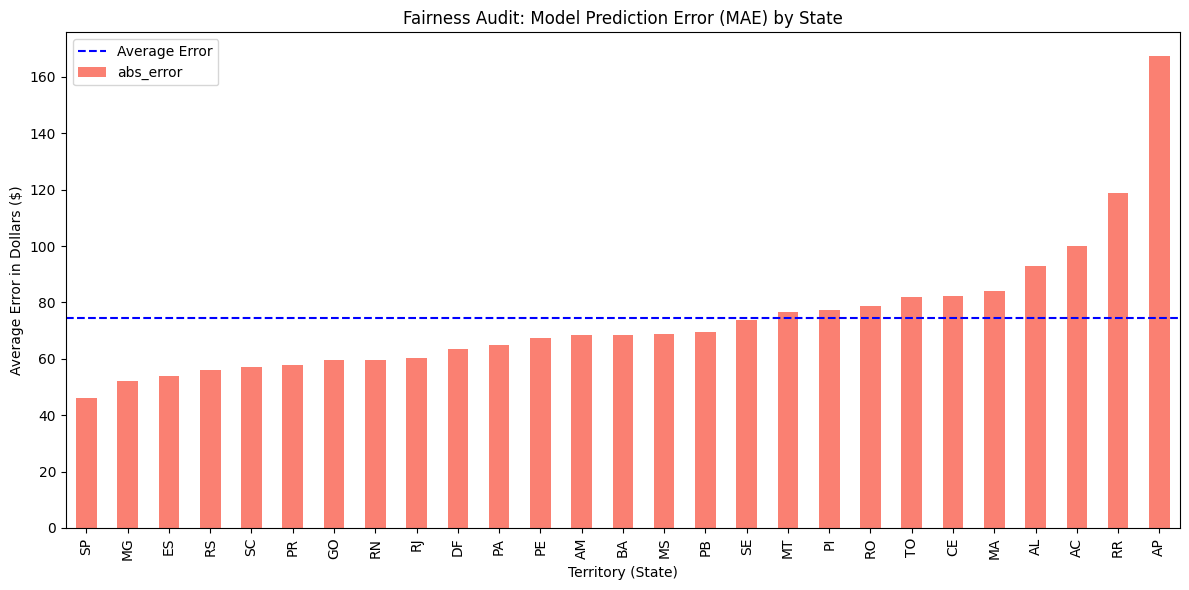

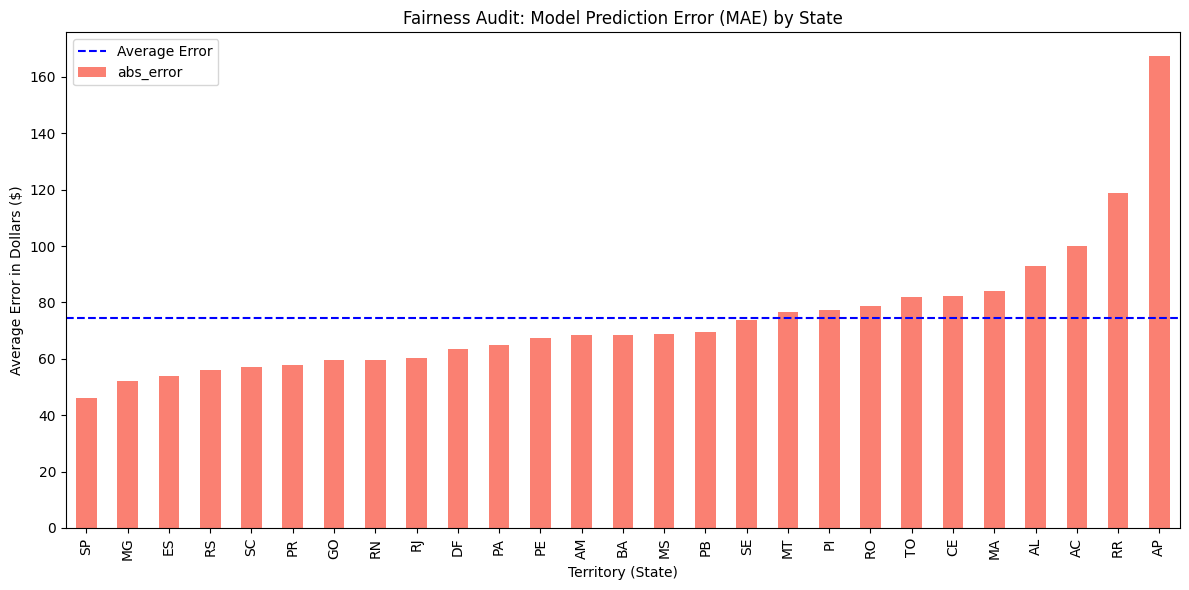

✅ Audit complete. Average MAE across all territories: $74.36


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load the winning model and prepare the audit dataframe
winning_model = joblib.load('models/random_forest_model.pkl')

# Re-align geography
test_indices = y_test.index
audit_df = customer_df.loc[test_indices].copy()

# Add Predictions and Actuals
audit_df['true_val'] = np.expm1(y_test)
audit_df['pred_val'] = np.expm1(winning_model.predict(X_test))
audit_df['abs_error'] = abs(audit_df['true_val'] - audit_df['pred_val'])

if 'customer_state' not in audit_df.columns:
    state_map = df[['customer_unique_id', 'customer_state']].drop_duplicates()
    audit_df = audit_df.merge(state_map, on='customer_unique_id', how='left')

# Calculate Mean Absolute Error (MAE) by State
state_bias = audit_df.groupby('customer_state')['abs_error'].mean().sort_values()

# Visualize the "Bias Map"
plt.figure(figsize=(12, 6))
state_bias.plot(kind='bar', color='salmon')
plt.axhline(y=state_bias.mean(), color='blue', linestyle='--', label='Average Error')
plt.title('Fairness Audit: Model Prediction Error (MAE) by State')
plt.ylabel('Average Error in Dollars ($)')
plt.xlabel('Territory (State)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"✅ Audit complete. Average MAE across all territories: ${state_bias.mean():.2f}")

# **E. Mitigations & Reproducibility**

Technical safeguards and artifact management:

**Ethical Mitigation:** Tiered Confidence Scores; agents in high-error regions receive a "Low Confidence" flag to prioritize human intuition.

**Future Strategy:** Regional re-weighting via over-sampling for remote regions.

**Artifacts:** Winning models (random_forest_model.pkl) and cluster definitions are serialized for immediate repository deployment.

# **F. Conclusion & Regional Transferability**

**Logical Bluprint:** Successfully accounting for logistical friction in Brazil provides a robust blueprint for Philippines-based operations.

**Scalability:** The model is prepared to simulate territory prioritization where margins are "eaten" by regional logistics costs.